# CNN Multi Dim Analysis

## 16-jan-2026

### Imports

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import json
import pandas as pd
import torch

from pathlib import Path

sys.path.insert(0, os.path.join(os.path.abspath(os.pardir), "src"))
from molearn.data import PDBData
from molearn.models.CNN_autoencoder import AutoEncoder
from molearn.analysis import MolearnAnalysis
from molearn.analysis.plot import *


### Loading Datasets and results

In [2]:
atoms = ["N", "CA", "C", "O", 'CB']

mean = json.load(open("../data/data_statistics_full.json"))["mean"]
std = json.load(open("../data/data_statistics_full.json"))["std"]

data_closed = PDBData(
    filename=["../data/full_MurD_closed.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_ = data_closed.prepare_dataset(mean=mean, std=std)

data_open = PDBData(
    filename=["../data/full_MurD_open.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_ = data_open.prepare_dataset(mean=mean, std=std)

data_test = PDBData(
    filename=["../data/MurD_closed_apo.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_ = data_test.prepare_dataset(mean=mean, std=std)


log_dfs = {}
min_valid_losses = {}
min_valid_mse_losses = {}
models = {}
MAs = {}

base_path = r"../results/16-jan-2026/cnn_multi_dim"

device = 'cuda' if torch.cuda.is_available() else 'cpu'

for n in range(2, 11):

    log_dfs[n] = pd.read_csv(Path(f"{base_path}/{n}/log.dat"))
    best_epoch = log_dfs[n]['valid_loss'].idxmin()
    min_valid_losses[n] = min(log_dfs[n].valid_loss)
    min_valid_mse_losses[n] = min(log_dfs[n].valid_mse_loss)

    checkpoint_path = Path(f"{base_path}/{n}/checkpoint_converged.ckpt")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    model = AutoEncoder(latent_dim=n)
    model.load_state_dict(checkpoint['model_state_dict'])

    models[n] = model

    MA = MolearnAnalysis() 
    MA.batch_size = 16
    MA.processes = 4

    MA.set_dataset(data=data_open, key="train_open")
    MA.set_dataset(data=data_closed, key="train_closed")
    MA.set_dataset(data=data_test, key="test_trans")

    MA.set_network(models[n])

    MAs[n] = MA

Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([2000, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([2000, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([900, 2145, 3])


### Model architecture and shapes

In [4]:
from molearn.models.CNN_autoencoder import ToND, FromND
from torch import nn


def print_encoder_shapes(model, n_atoms):
    """Print the shape at each stage of the encoder"""
    # Create dummy input: (batch=1, atoms=n_atoms, coords=3)
    x = torch.randn(1, n_atoms, 3)
    
    # Permute to (batch, 3, atoms) as encoder expects
    x = x.permute(0, 2, 1)
    print(f"Input shape: {x.shape}")
    
    for i, m in enumerate(model.encoder):
        if isinstance(m, ToND):
            # ToND expects unsqueezed input
            x_unsqueezed = x.unsqueeze(-1)
            print(f"  After unsqueeze(-1): {x_unsqueezed.shape}")
            x = m(x_unsqueezed)
        else:
            x = m(x)
        
        # Print shape after certain layer types
        if isinstance(m, (nn.Conv1d, nn.ConvTranspose1d, ToND, FromND)):
            print(f"Layer {i} ({m.__class__.__name__}): {x.shape}")
    
    print(f"\nFinal latent shape: {x.shape}")
    return x

# Test with your model

latent_dim = 3

print("=" * 60)
print(f"ENCODER FORWARD PASS - latent_dim={latent_dim}")
print("=" * 60)
z = print_encoder_shapes(models[latent_dim], n_atoms=data_open.dataset.shape[1])
print(data_open.dataset.shape)

ENCODER FORWARD PASS - latent_dim=3
Input shape: torch.Size([1, 3, 2145])
Layer 0 (Conv1d): torch.Size([1, 32, 1072])
Layer 3 (Conv1d): torch.Size([1, 48, 536])
Layer 6 (Conv1d): torch.Size([1, 72, 268])
Layer 9 (Conv1d): torch.Size([1, 108, 134])
Layer 12 (Conv1d): torch.Size([1, 162, 67])
Layer 15 (Conv1d): torch.Size([1, 1, 33])
  After unsqueeze(-1): torch.Size([1, 1, 33, 1])
Layer 16 (ToND): torch.Size([1, 3])

Final latent shape: torch.Size([1, 3])
torch.Size([2000, 2145, 3])


### MSE Plots 

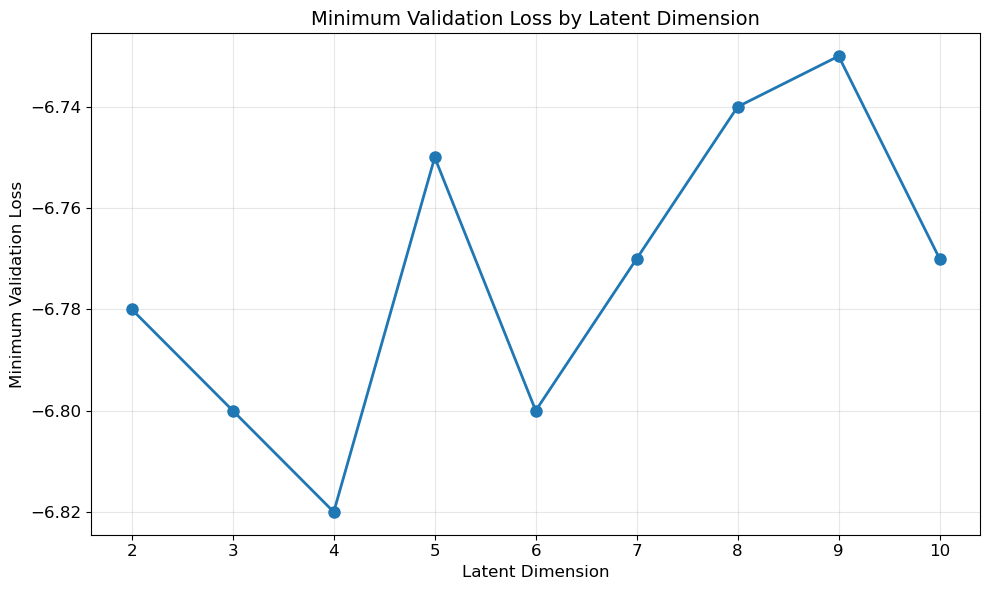

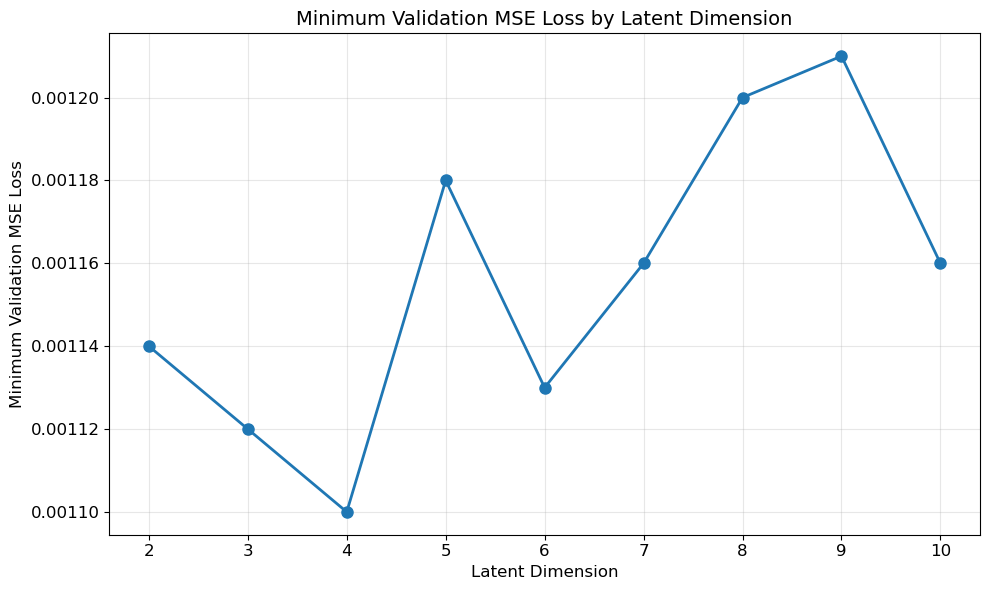

In [5]:
# Plot line graph of minimum validation losses
plt.figure(figsize=(10, 6))
plt.plot(list(min_valid_losses.keys()), list(min_valid_losses.values()), marker='o', linewidth=2, markersize=8)
plt.xlabel('Latent Dimension', fontsize=12)
plt.ylabel('Minimum Validation Loss', fontsize=12)
plt.title('Minimum Validation Loss by Latent Dimension', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot line graph of minimum validation MSE_losses
plt.figure(figsize=(10, 6))
plt.plot(list(min_valid_mse_losses.keys()), list(min_valid_mse_losses.values()), marker='o', linewidth=2, markersize=8)
plt.xlabel('Latent Dimension', fontsize=12)
plt.ylabel('Minimum Validation MSE Loss', fontsize=12)
plt.title('Minimum Validation MSE Loss by Latent Dimension', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### Model plots

#### RMSD Hist plot

encoding train_open: 125it [00:01, 95.30it/s]
Decoding train_open: 125it [00:01, 97.92it/s] 
encoding train_closed: 125it [00:02, 57.32it/s]
Decoding train_closed: 125it [00:01, 107.67it/s]
encoding test_trans: 57it [00:00, 75.98it/s]
Decoding test_trans: 57it [00:00, 94.78it/s]


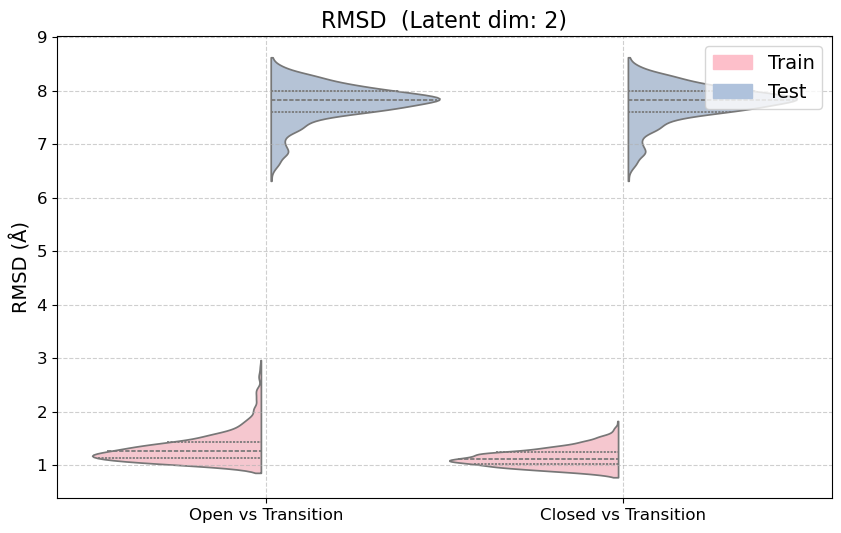

encoding train_open: 125it [00:01, 75.79it/s]
Decoding train_open: 125it [00:01, 87.75it/s]
encoding train_closed: 65it [00:00, 94.52it/s] 


KeyboardInterrupt: 

In [6]:
from molearn.analysis.plot import plot_rmsd_hist

latent_dims = [2, 4, 10]

for latent_dim in latent_dims:
    rmsd_train_open = MAs[latent_dim].get_error('train_open')
    rmsd_train_closed = MAs[latent_dim].get_error('train_closed')
    rmsd_test_trans = MAs[latent_dim].get_error('test_trans')

    rmsd_plot_data = [
        ("train_open", "test_trans", "Open vs Transition", "train", "test"),
        ("train_closed", "test_trans", "Closed vs Transition", "train", "test"),
    ]

    plot_rmsd_hist(
        MAs[latent_dim],
        plot_data=rmsd_plot_data,
        dpi=150,
        latent_dim=latent_dim,
    )

#### Bondlength Hist plots

BOND LENGTH DISTRIBUTIONS - latent_dim=2


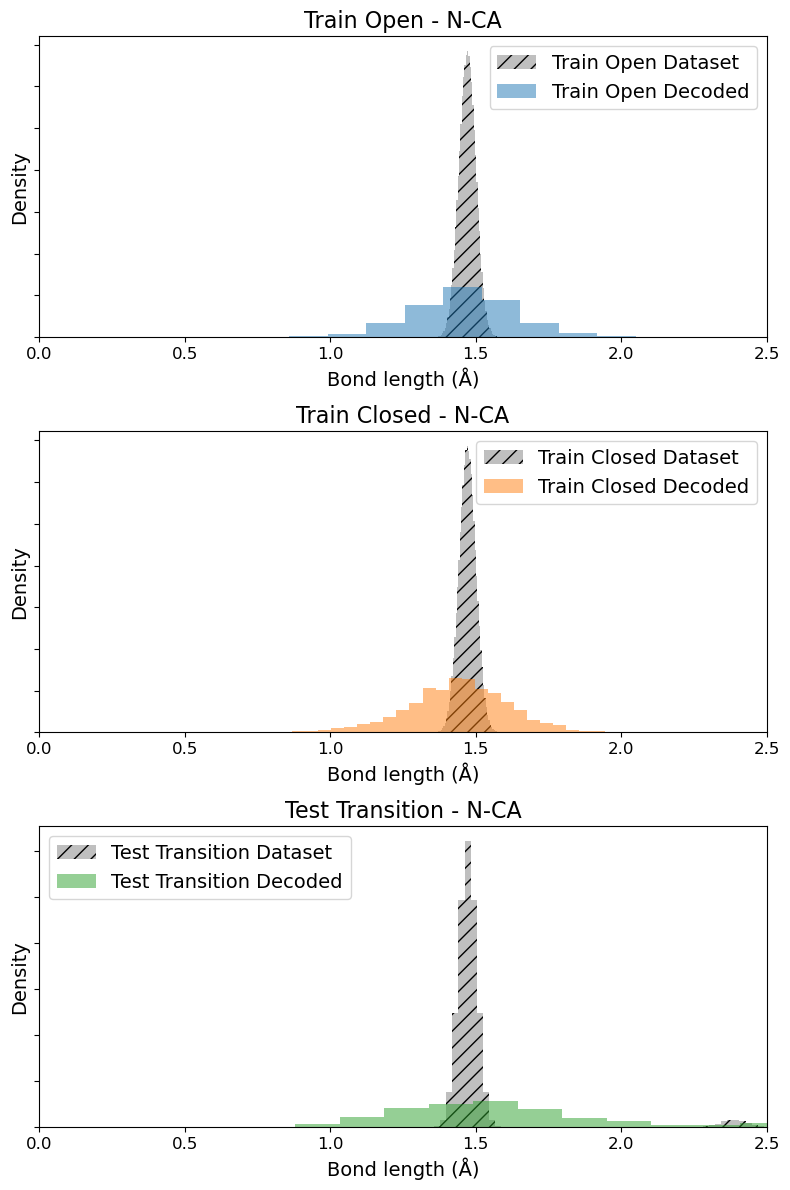

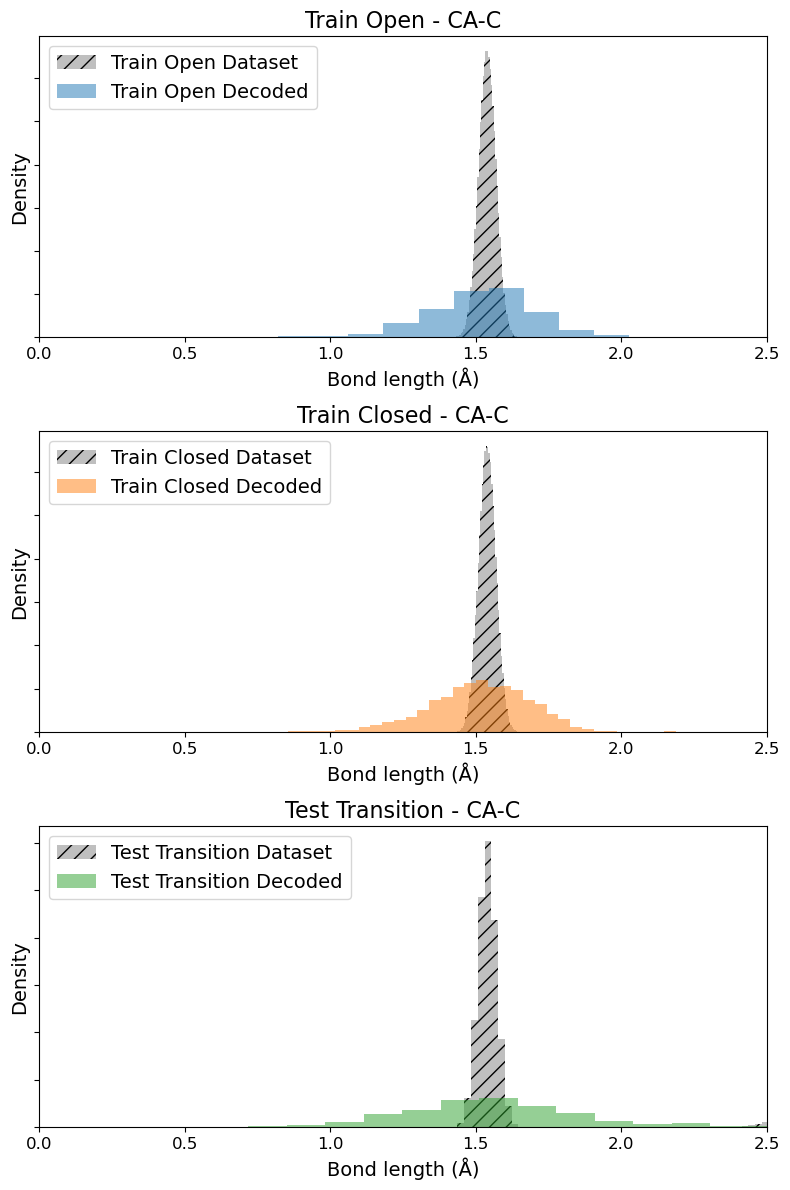

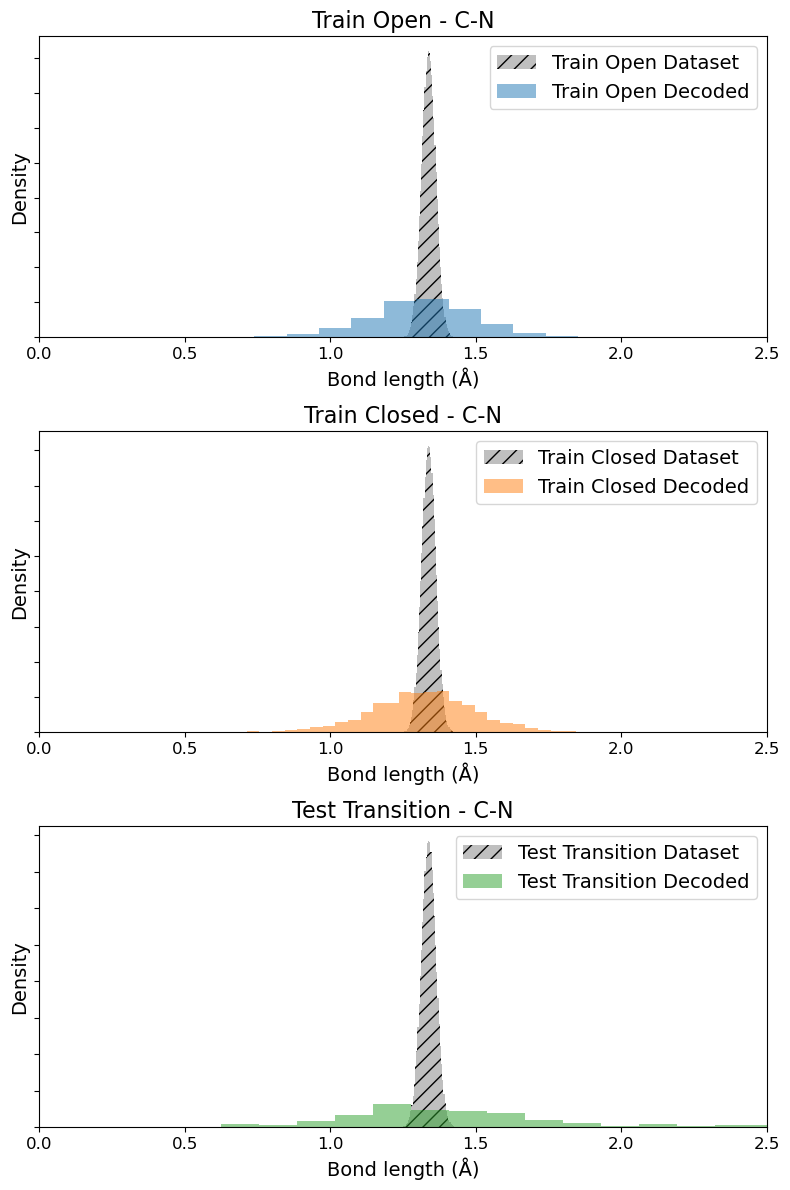

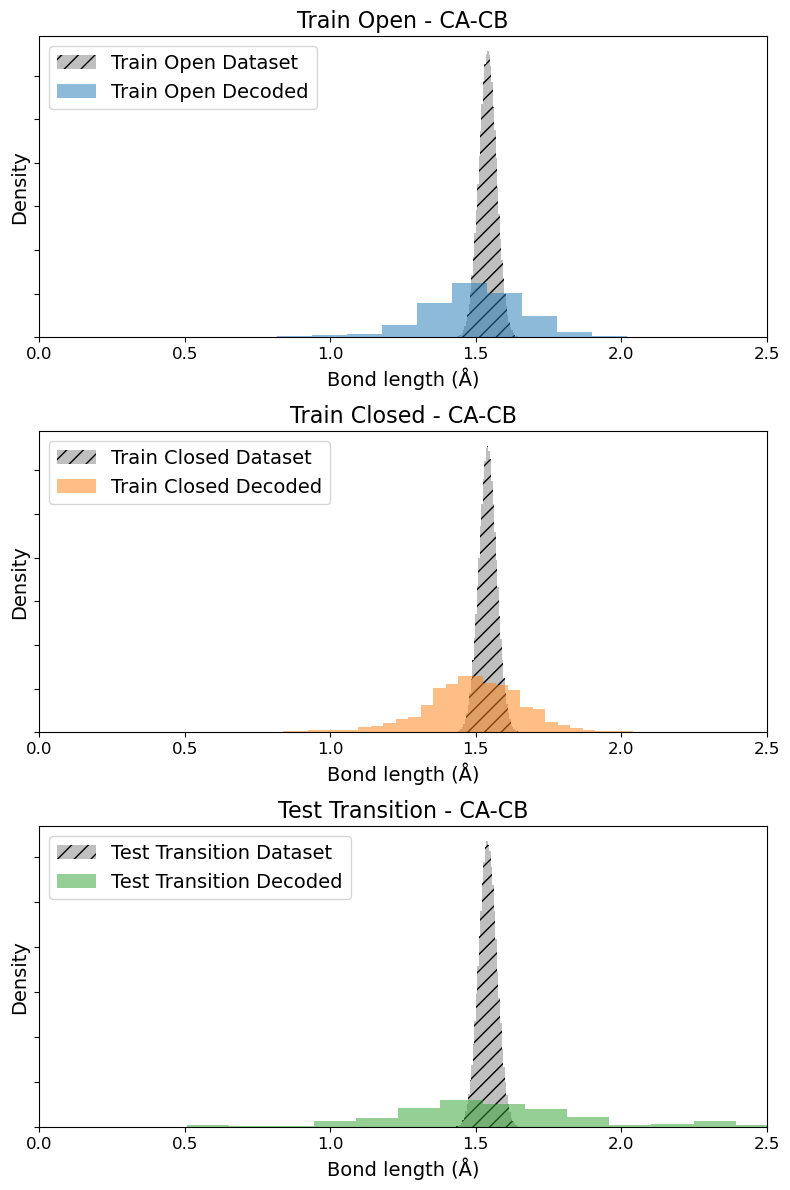

BOND LENGTH DISTRIBUTIONS - latent_dim=4


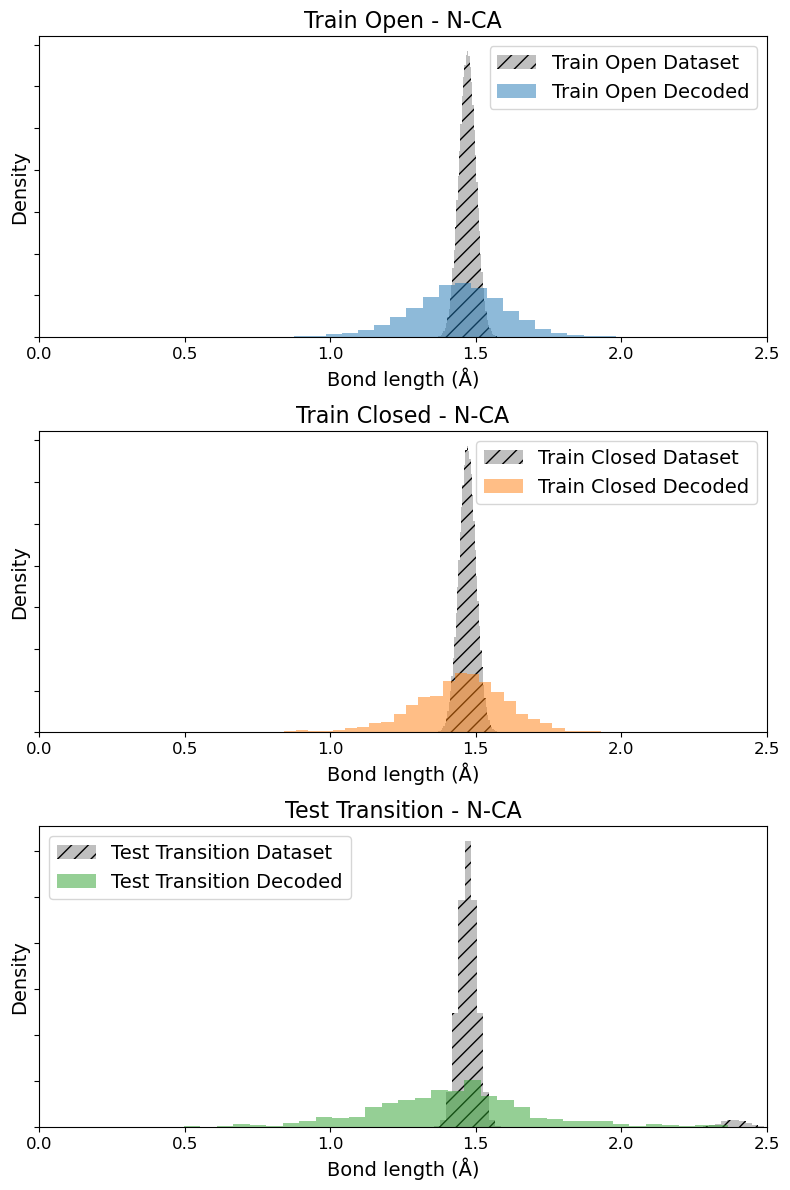

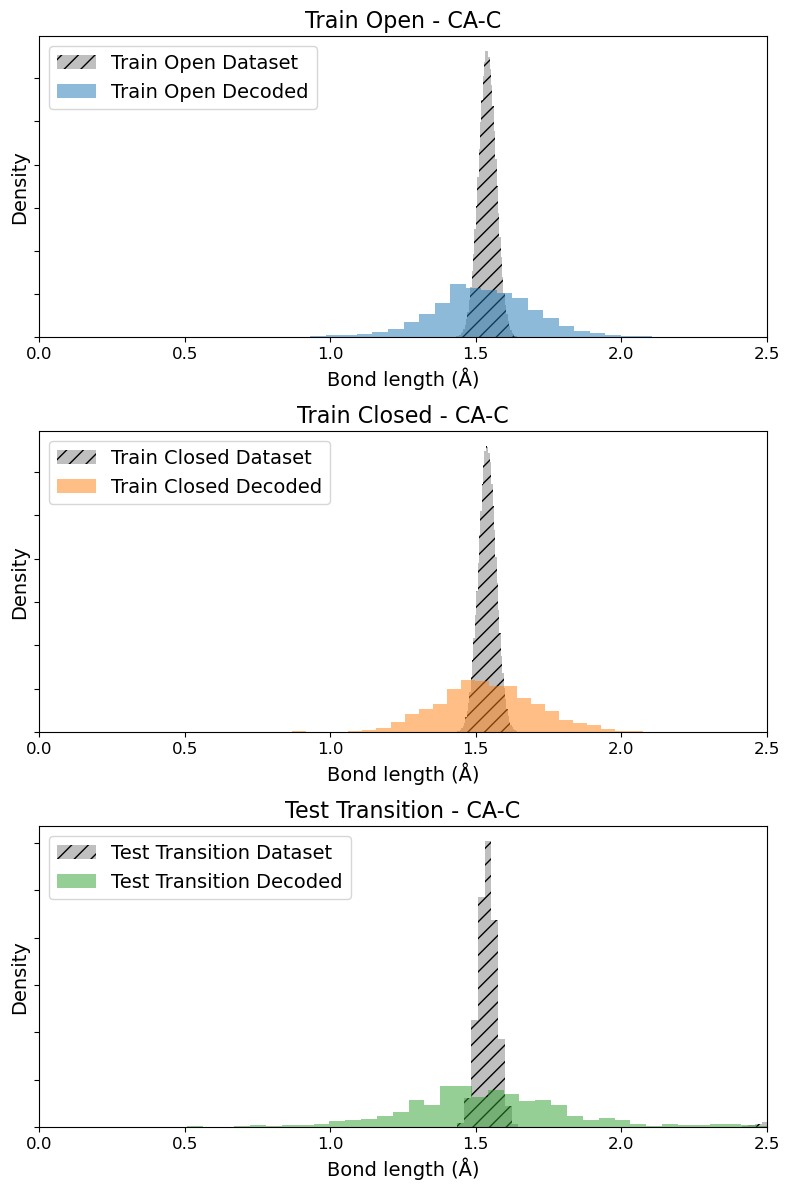

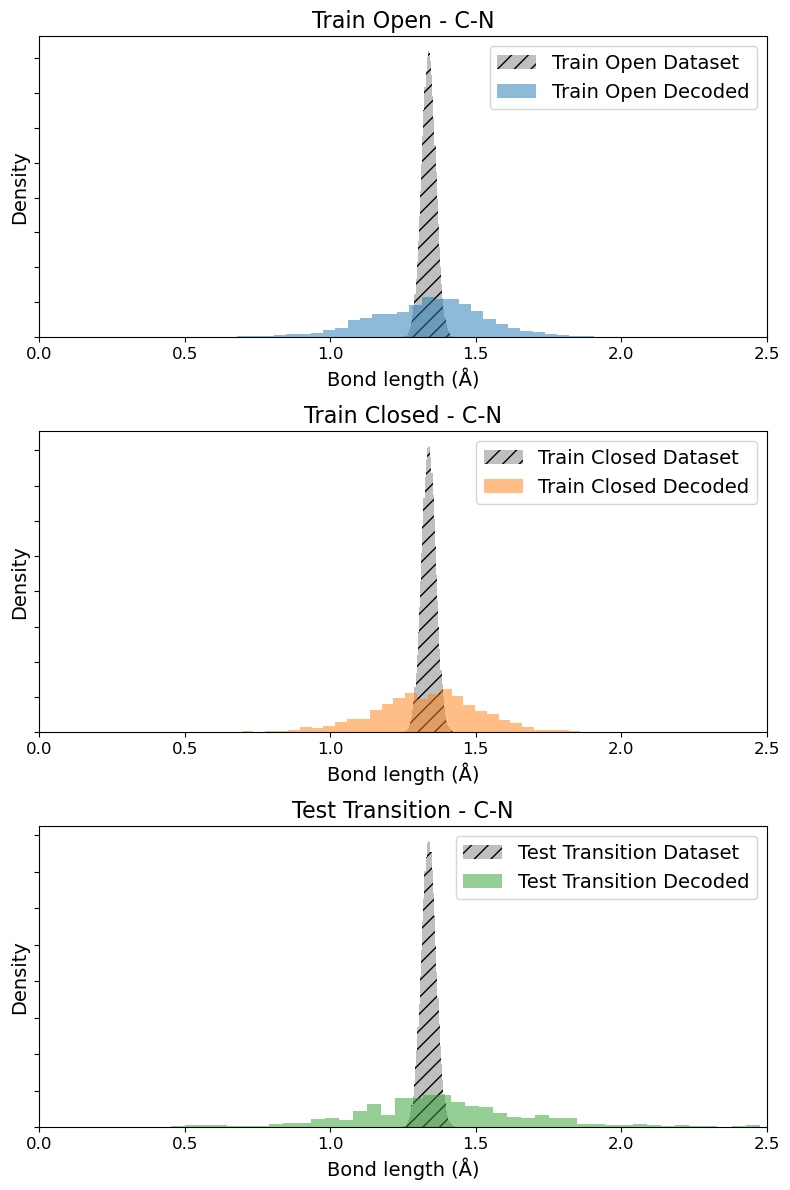

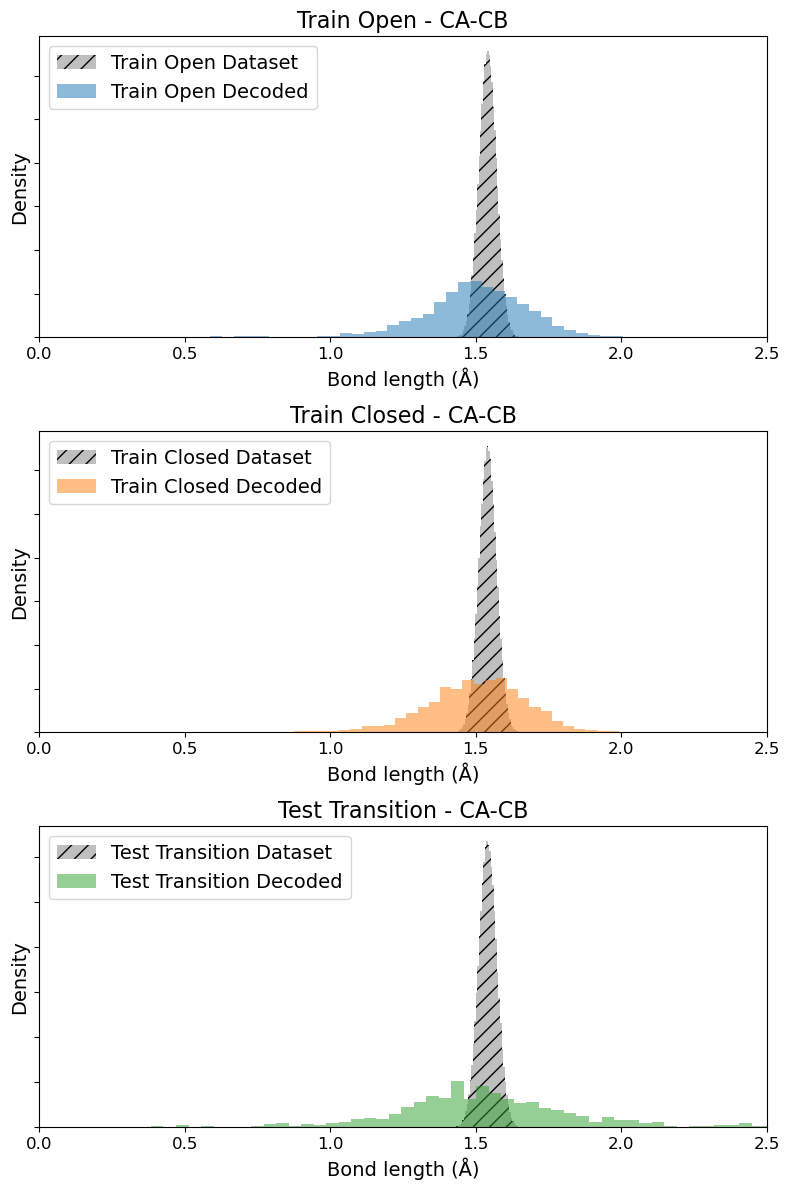

BOND LENGTH DISTRIBUTIONS - latent_dim=10


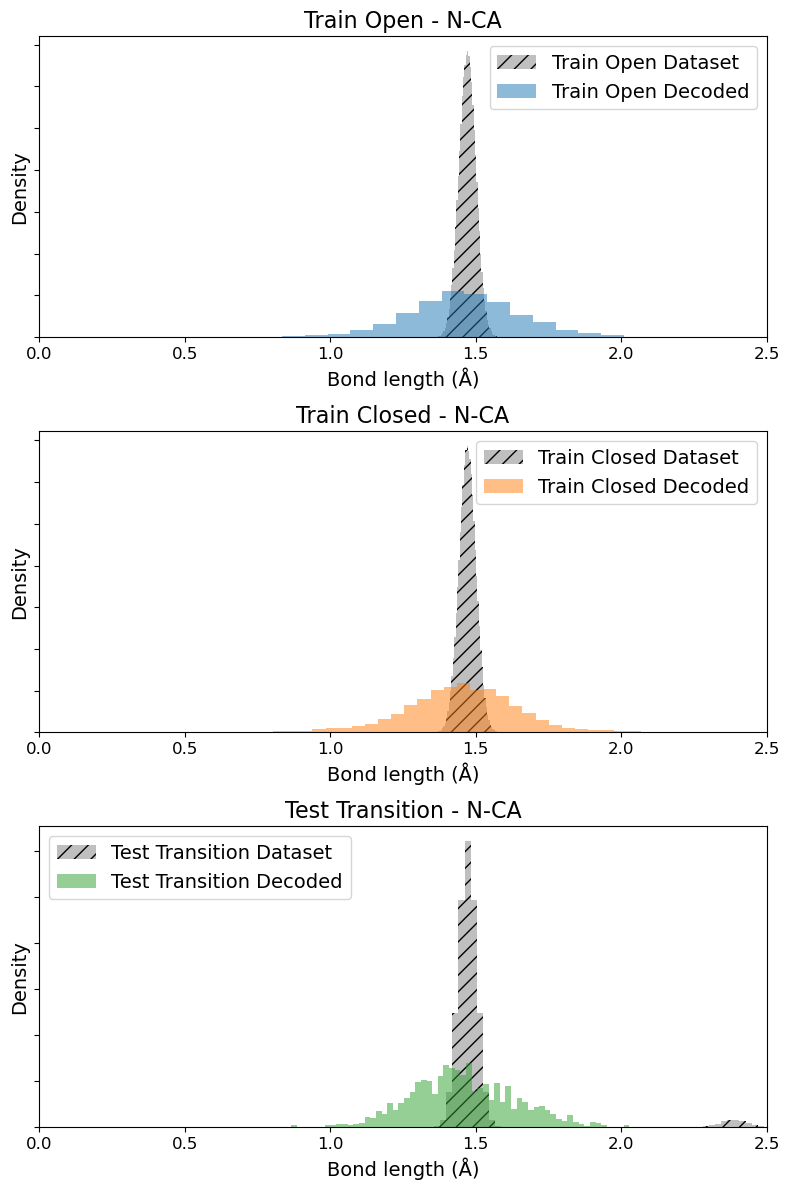

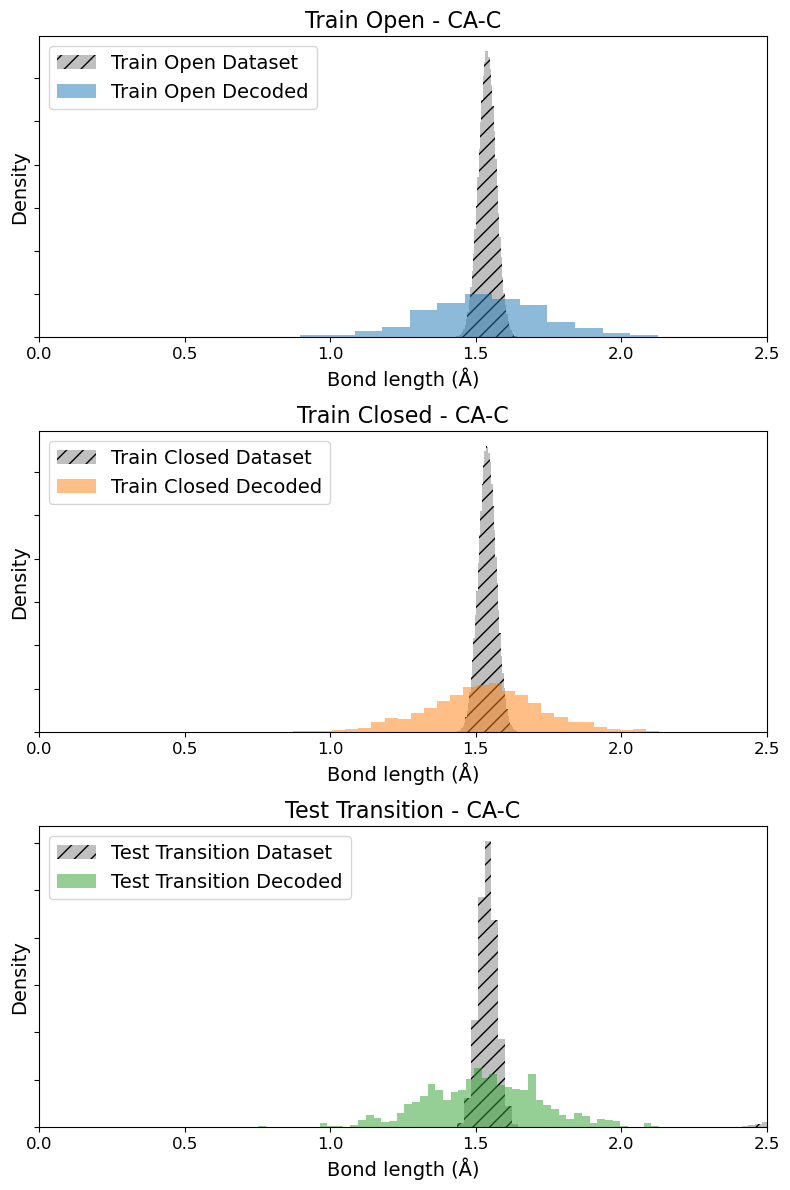

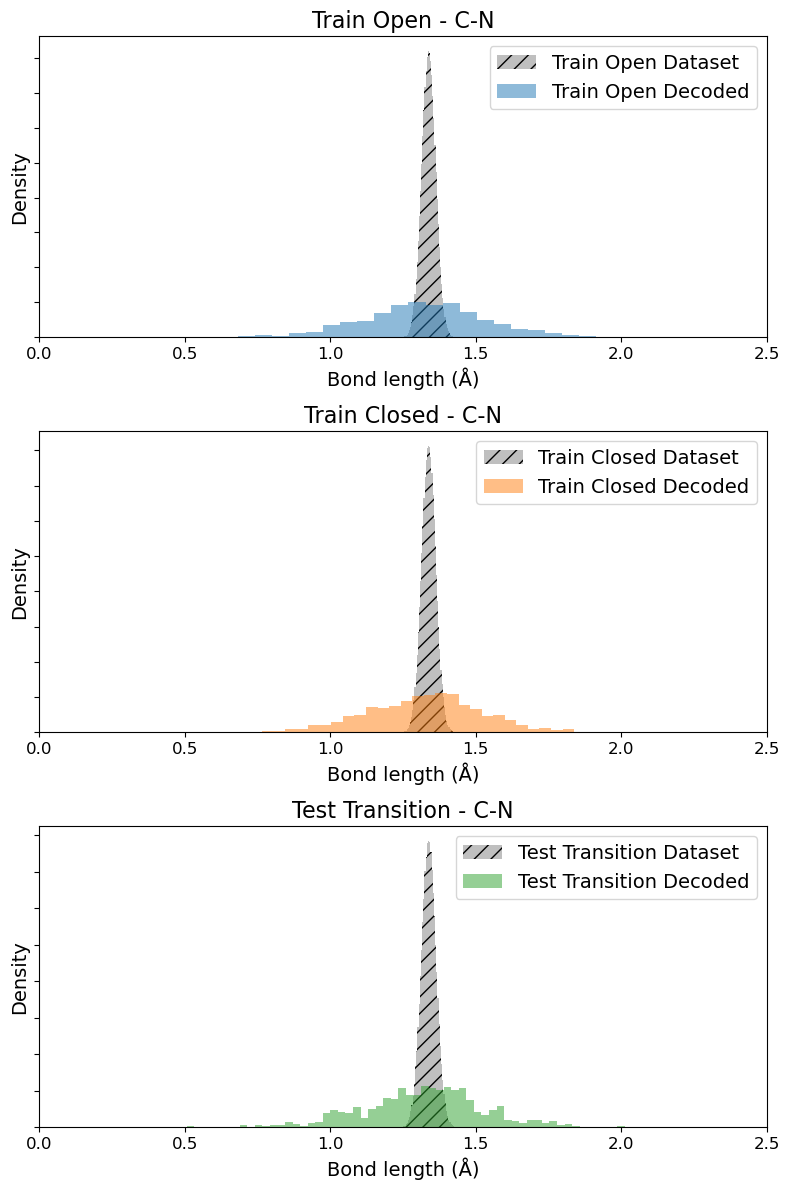

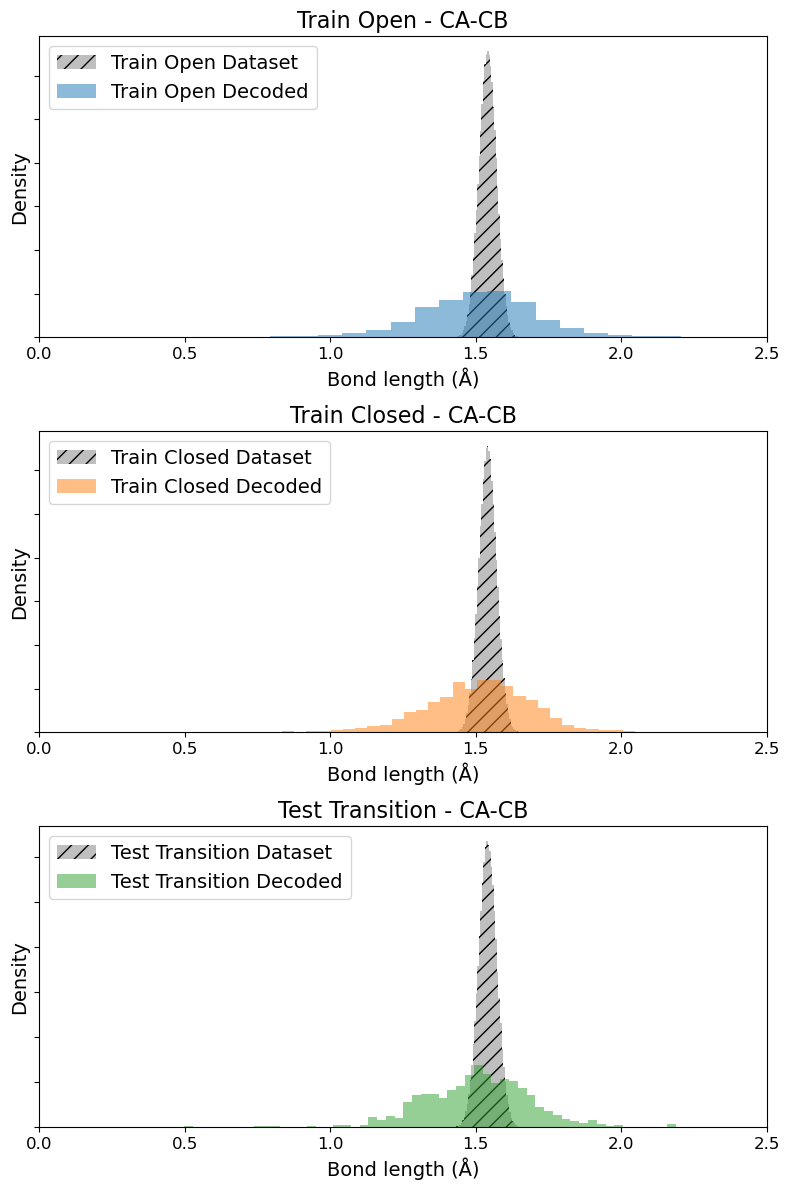

In [ ]:
%load_ext autoreload
%autoreload 2

from molearn.analysis.plot import plot_bondlength_hist

for latent_dim in latent_dims:

    print("=" * 60)
    print(f"BOND LENGTH DISTRIBUTIONS - latent_dim={latent_dim}")
    print("=" * 60)
    
    bondlength_train_open = MAs[latent_dim].get_bondlengths('train_open')
    bondlength_train_closed = MAs[latent_dim].get_bondlengths('train_closed')
    bondlength_test_trans = MAs[latent_dim].get_bondlengths('test_trans')

    bondlength_plot_data = [
        ("train_open", "Train Open", "#1f77b4"),
        ("train_closed", "Train Closed", "#ff7f0e"),
        ("test_trans", "Test Transition", "#2ca02c"),
    ]

    plot_bondlength_hist(
        MAs[latent_dim],
        plot_data=bondlength_plot_data,
        bins=60,
        dpi=150,
    )

#### Inversion Hist Plot

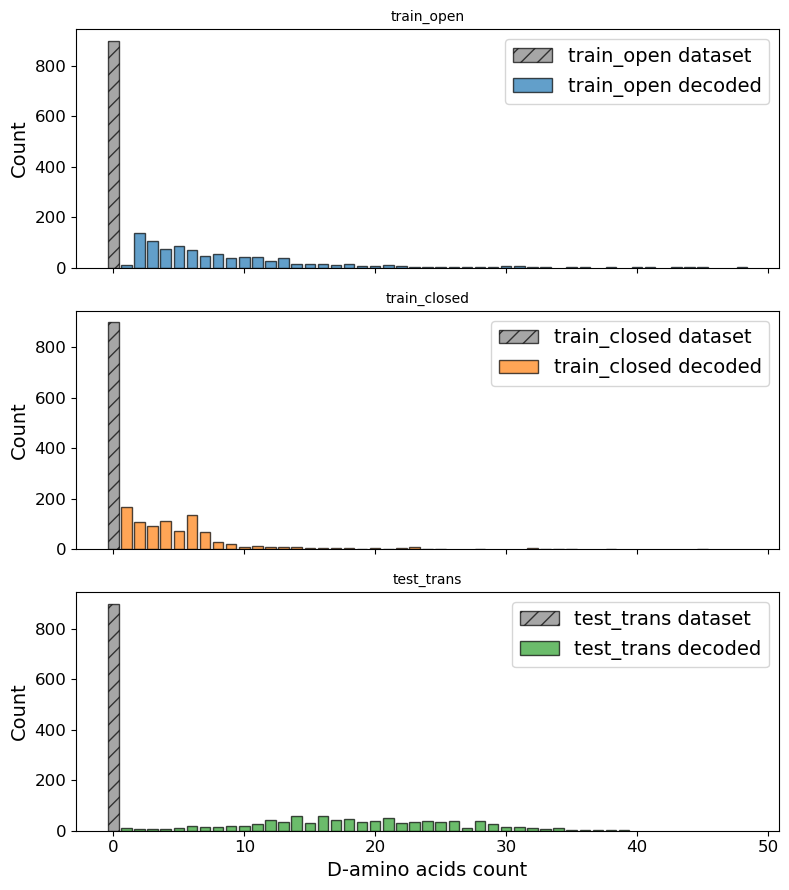

In [ ]:
inversion_plot_data = [('train_open', 'train_open', "#1f77b4"),
                       ('train_closed', 'train_closed',"#ff7f0e"),
                       ('test_trans', 'test_trans', "#2ca02c")]

plot_inversion_hist(MAs[2], 
                    plot_data = inversion_plot_data,
                    )

#### Dope score as a grid (2D only)

Latent grid 'grid' initialised with 20 samples per axis.


Calc Dope:   0%|          | 0/400 [00:00<?, ?it/s]

Calc Dope: 100%|██████████| 400/400 [00:28<00:00, 14.17it/s]


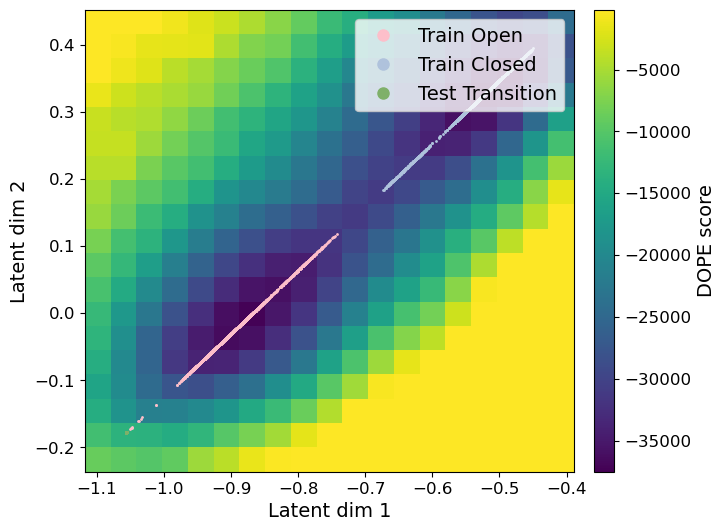

In [ ]:
for latent_dim in [2]:


    if "grid" not in MAs[latent_dim]._encoded:
        grid_key = MAs[latent_dim].setup_grid(samples=20) #kernel restart is required to change this value
        print(f"Latent grid '{grid_key}' initialised with {MAs[latent_dim].n_samples} samples per axis.")
    else:
        grid_key = "grid"
        print("Re-using previously initialised latent grid.")

    refine = True

    dope_surface, xvals, yvals = MAs[latent_dim].scan_dope(refine=refine)
    surface_clip = np.percentile(dope_surface, 80)

    dope_plot_data = [
        ("train_open", "Train Open", "#FDBFCA", "scatter"),
        ("train_closed", "Train Closed", "#AFC2DC", "scatter"),
        ("test_trans", "Test Transition", "#7FB069", "scatter"),
    ]

    plot_dope_surface(
        MAs[latent_dim],
        refine=refine,
        truncate_at=surface_clip,
        plot_data=dope_plot_data,
        cmap="viridis",
        bbox_inches="tight",
    )

### PCA

In [17]:
def subsample_if_needed(data, use_partial, step=100):
    return data[::step] if use_partial else data

latent_dims = [2, 3, 7, 10]
refine = False
use_partial_data = False

dope_scores = {}
latent_pca_dict = {}
latent_original_dict = {} 

from sklearn.decomposition import PCA

for latent_dim in latent_dims:

    # # Getting subsampled datasets
    # train_open_data = subsample_if_needed(MAs[latent_dim].get_dataset('train_open', scale=True), use_partial_data)
    # train_closed_data = subsample_if_needed(MAs[latent_dim].get_dataset('train_closed', scale=True), use_partial_data)
    # test_trans_data = subsample_if_needed(MAs[latent_dim].get_dataset('test_trans', scale=True), use_partial_data)
    
    # # Getting DOPE scores
    # dope_scores[latent_dim] = {
    #     'train_open': MAs[latent_dim].get_all_dope_score(train_open_data, refine=refine),
    #     'train_closed': MAs[latent_dim].get_all_dope_score(train_closed_data, refine=refine),
    #     'test_trans': MAs[latent_dim].get_all_dope_score(test_trans_data, refine=refine),
    # }
    
    # Getting latent encodings
    latent_train_open = subsample_if_needed(MAs[latent_dim].get_encoded('train_open'), use_partial_data)
    latent_train_closed = subsample_if_needed(MAs[latent_dim].get_encoded('train_closed'), use_partial_data)
    latent_test = subsample_if_needed(MAs[latent_dim].get_encoded('test_trans'), use_partial_data)

    # # Storing original latent codes
    # latent_original_dict[latent_dim] = {
    #     'train_open': latent_train_open,
    #     'train_closed': latent_train_closed,
    #     'test_trans': latent_test,
    # }
    
    # Applying PCA
    pca = PCA(n_components=2)
    # latent_all = np.vstack((latent_train_open, latent_train_closed, latent_test))

    print(latent_train_open.shape)

    # Add this debug code before pca.fit()
    print(f"latent_train_open shape: {latent_train_open.shape}")
    print(f"Min per dim: {latent_train_open.min(axis=0)}")
    print(f"Max per dim: {latent_train_open.max(axis=0)}")
    print(f"Std per dim: {latent_train_open.std(axis=0)}")
    print(f"Mean per dim: {latent_train_open.mean(axis=0)}")

    # Check if it's a tensor that needs converting
    print(f"Type: {type(latent_train_open)}")

    # Check for NaN or Inf
    print(f"Has NaN: {np.isnan(latent_train_open).any()}")
    print(f"Has Inf: {np.isinf(latent_train_open).any()}")

    # Check the covariance matrix
    cov = np.cov(latent_train_open.T)
    print(f"Covariance matrix:\n{cov}")
    print(f"Eigenvalues: {np.linalg.eigvalsh(cov)}")

    pca.fit(latent_train_open)

    var_pc1 = pca.explained_variance_ratio_[0] * 100
    var_pc2 = pca.explained_variance_ratio_[1] * 100
    var_total = (var_pc1 + var_pc2)
    
    print(f"Latent Dim {latent_dim}: PCA variance explained - PC1: {var_pc1:.2f}%, PC2: {var_pc2:.2f}%, Total: {var_total:.2f}%")

    # # Storing PCA results
    # latent_pca_dict[latent_dim] = {
    #     'train_open': pca.transform(latent_train_open),
    #     'train_closed': pca.transform(latent_train_closed),
    #     'test_trans': pca.transform(latent_test),
    # }
    
    # # Plotting data specification
    # pca_plot_data = [
    #     ('train_open', 'Train Open', '#FDBFCA'),
    #     ('train_closed', 'Train Closed', '#AFC2DC'),
    #     ('test_trans', 'Test Transition', '#7FB069'),
    # ]
    
    # plot_pca_latent_space(
    #     MAs[latent_dim],
    #     latent_pca_dict[latent_dim],
    #     dope_scores[latent_dim],
    #     plot_data=pca_plot_data,
    #     latent_dim=latent_dim,
    #     latent_original_dict=latent_original_dict[latent_dim],
    #     dpi=150,
    # )















encoding train_open: 125it [00:01, 69.47it/s]














encoding train_closed: 125it [00:01, 83.22it/s]






encoding test_trans: 57it [00:00, 102.36it/s]


torch.Size([2000, 2])
latent_train_open shape: torch.Size([2000, 2])
Min per dim: torch.return_types.min(
values=tensor([-1.0500, -0.1722]),
indices=tensor([1505, 1505]))
Max per dim: torch.return_types.max(
values=tensor([-0.7422,  0.1185]),
indices=tensor([214, 214]))
Std per dim: tensor([0.0488, 0.0460])
Mean per dim: tensor([-0.8889, -0.0201])
Type: <class 'torch.Tensor'>
Has NaN: 0
Has Inf: 0
Covariance matrix:
[[0.00237842 0.00224541]
 [0.00224541 0.00211984]]
Eigenvalues: [5.08707659e-16 4.49826023e-03]
Latent Dim 2: PCA variance explained - PC1: 100.00%, PC2: 0.00%, Total: 100.00%
torch.Size([2000, 3])
latent_train_open shape: torch.Size([2000, 3])
Min per dim: torch.return_types.min(
values=tensor([-0.4730, -0.5546,  0.2310]),
indices=tensor([180, 180, 367]))
Max per dim: torch.return_types.max(
values=tensor([-0.3389, -0.2792,  0.4369]),
indices=tensor([367, 367, 180]))
Std per dim: tensor([0.0267, 0.0548, 0.0410])
Mean per dim: tensor([-0.3928, -0.3898,  0.3137])
Type: <clas














encoding train_open: 125it [00:01, 94.49it/s]












encoding train_closed: 125it [00:01, 90.78it/s]







encoding test_trans: 57it [00:00, 57.35it/s]


torch.Size([2000, 7])
latent_train_open shape: torch.Size([2000, 7])
Min per dim: torch.return_types.min(
values=tensor([-0.3247, -0.7691, -0.0460, -0.3300, -0.0099,  0.0404, -0.5018]),
indices=tensor([1503, 1503,  214, 1503, 1503,  214, 1503]))
Max per dim: torch.return_types.max(
values=tensor([ 0.0040, -0.5208,  0.0622, -0.2902,  0.1158,  0.2009, -0.1868]),
indices=tensor([ 214,  214, 1503,  214,  214, 1503,  214]))
Std per dim: tensor([0.0505, 0.0381, 0.0166, 0.0061, 0.0193, 0.0246, 0.0484])
Mean per dim: tensor([-0.1288, -0.6211, -0.0023, -0.3063,  0.0650,  0.1052, -0.3141])
Type: <class 'torch.Tensor'>
Has NaN: 0
Has Inf: 0
Covariance matrix:
[[ 2.54901917e-03  1.92541795e-03 -8.38989863e-04  3.09101728e-04
   9.75148666e-04 -1.24441592e-03  2.44327791e-03]
 [ 1.92541795e-03  1.45437677e-03 -6.33736365e-04  2.33481969e-04
   7.36584788e-04 -9.39977529e-04  1.84554561e-03]
 [-8.38989863e-04 -6.33736365e-04  2.76146998e-04 -1.01738433e-04
  -3.20962611e-04  4.09589835e-04 -8.041859














encoding train_open: 125it [00:01, 96.63it/s]













encoding train_closed: 125it [00:01, 91.37it/s]






encoding test_trans: 57it [00:00, 91.90it/s]

torch.Size([2000, 10])
latent_train_open shape: torch.Size([2000, 10])
Min per dim: torch.return_types.min(
values=tensor([ 0.1458, -0.0833, -0.0538,  0.4772, -0.0954, -0.7743, -0.1107, -0.2109,
        -0.4107, -0.0659]),
indices=tensor([367, 367, 367, 178, 178, 367, 367, 178, 367, 178]))
Max per dim: torch.return_types.max(
values=tensor([ 0.2574, -0.0416,  0.1089,  0.7532,  0.0807, -0.4810,  0.0696, -0.1728,
        -0.2088,  0.1813]),
indices=tensor([178, 178, 178, 367, 367, 178, 178, 367, 178, 367]))
Std per dim: tensor([0.0223, 0.0083, 0.0325, 0.0552, 0.0352, 0.0586, 0.0360, 0.0076, 0.0404,
        0.0494])
Mean per dim: tensor([ 0.2020, -0.0623,  0.0280,  0.6144, -0.0079, -0.6267, -0.0200, -0.1920,
        -0.3092,  0.0570])
Type: <class 'torch.Tensor'>
Has NaN: 0
Has Inf: 0
Covariance matrix:
[[ 4.97826217e-04  1.86258112e-04  7.25434074e-04 -1.23085408e-03
  -7.85568966e-04  1.30799515e-03  8.04007611e-04 -1.69576328e-04
   9.00523773e-04 -1.10273624e-03]
 [ 1.86258112e-04  6.